### Document: https://docs.google.com/document/d/1MQRRvijGePyH-NZnXzTHJqW-1nKM7XJqG3KAeLhcaP8/edit?usp=sharing
### Task description: https://drive.google.com/file/d/10kHzwypxfNLZQdXYa3gvdy5jnEXdeqkI/view

# Step 1

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [ ]:
# -----------------------------------------------------------------
# HELPER FUNCTIONS
# -----------------------------------------------------------------

def run_adf_test(series, series_name):
    """
    Runs the Augmented Dickey-Fuller test and prints the results.
    """
    print(f"--- ADF Test Results for: {series_name} ---")

    # Drop NaNs which can cause the test to fail
    series_cleaned = series.dropna()

    if len(series_cleaned) < 50:
        print("Not enough data to run ADF test.")
        print("-" * 40 + "\n")
        return

    # Run the test
    result = adfuller(series_cleaned)

    # Print results
    print(f'Test Statistic: {result[0]:.4f}')
    print(f'P-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')

    # Interpretation
    if result[1] > 0.05:
        print(f"\nConclusion: P-value ({result[1]:.4f}) > 0.05. \
Fail to reject H0. Series is NON-STATIONARY.")
    else:
        print(f"\nConclusion: P-value ({result[1]:.4f}) <= 0.05. \
Reject H0. Series is STATIONARY.")
    print("-" * 40 + "\n")

def get_weights_ffd(d, n_k):
    """
    Computes the weights for fractional differencing (Fixed-Width Window).
    """
    w_k = [1]
    for k in range(1, n_k):
        w_k.append(-w_k[-1] * (d - k + 1) / k)

    w_k = np.array(w_k).reshape(-1, 1)
    return w_k

def fractional_diff_ffd(series, d, thresh=1e-5):
    """
    Applies fractional differencing to a series without an external library.
    """
    # 1. Compute weights
    n_k = 1
    weights = get_weights_ffd(d, n_k)
    while np.abs(weights[-1, 0]) > thresh:
        n_k += 1
        weights = get_weights_ffd(d, n_k)
        if n_k > 2000: # Safety break for very large d
             break

    n_k = min(n_k, len(series)-1) # Cap weights at series length
    weights = weights[:n_k] # Final weights

    # 2. Apply weights
    diff_series = pd.Series(index=series.index, dtype='float64')

    # We can't compute the first 'n_k' values, they will be NaN
    for i in range(n_k, len(series)):
        window = series.iloc[i-n_k : i].values

        # Apply dot product, reversing weights to match series order
        diff_val = series.iloc[i] + np.dot(weights.T[::-1], window.reshape(-1,1))[0,0]
        diff_series.iloc[i] = diff_val

    return diff_series # NaNs will be present at the start

## 1.a


===== Starting Step 1.a: Price Levels =====


[*********************100%***********************]  1 of 1 completed



--- Summary Statistics (Levels) ---
Ticker        ^GSPC
count   2000.000000
mean    4105.392784
std     1144.588344
min     2237.399902
25%     2991.997559
50%     4047.029907
75%     4704.607544
max     6890.890137


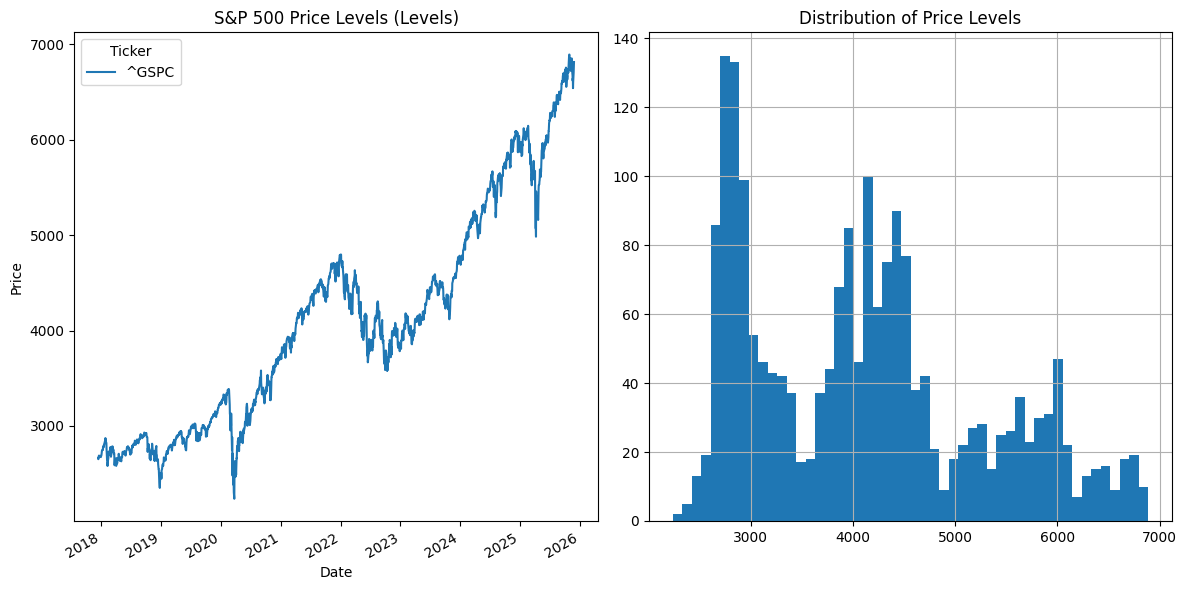

--- ADF Test Results for: Price Levels ---
Test Statistic: 0.3569
P-value: 0.9798
Critical Values:
	1%: -3.4336
	5%: -2.8630
	10%: -2.5675

Conclusion: P-value (0.9798) > 0.05. Fail to reject H0. Series is NON-STATIONARY.
----------------------------------------



In [ ]:
# -----------------------------------------------------------------
# STEP 1.a: Gather and Analyze Price Levels
# -----------------------------------------------------------------
print("\n===== Starting Step 1.a: Price Levels =====")

# Gather data (max 2,000 observations as per instructions)
data = yf.download('^GSPC', period='2000d', interval='1d', auto_adjust=False)
data = data[['Close']].copy() # We only care about the closing price


# 1.a - Characterization: Visualization
print("\n--- Summary Statistics (Levels) ---")
print(data['Close'].describe())
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Plot 1: Time Series
data['Close'].plot(ax=axes[0], title='S&P 500 Price Levels (Levels)')
axes[0].set_ylabel('Price')

# Plot 2: Histogram
data['Close'].hist(ax=axes[1], bins=50)
axes[1].set_title('Distribution of Price Levels')

fig.tight_layout()
plt.show()

# 1.a - Characterization: Stationarity (ADF Test)
run_adf_test(data['Close'], 'Price Levels')

## 1.b

===== Starting Step 1.b: Log Returns =====

--- Summary Statistics (Log Returns) ---
count    1999.000000
mean        0.000470
std         0.012407
min        -0.127652
25%        -0.004454
50%         0.000898
75%         0.006588
max         0.090895
Name: Log_Returns, dtype: float64


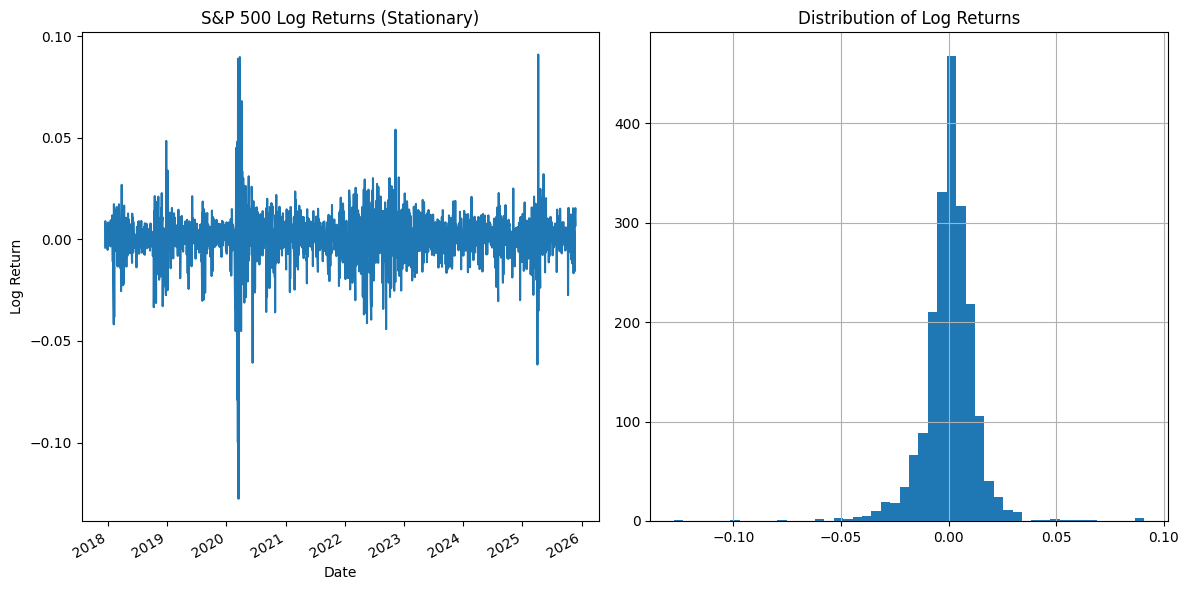

--- ADF Test Results for: Log Returns ---
Test Statistic: -14.0790
P-value: 0.0000
Critical Values:
	1%: -3.4336
	5%: -2.8630
	10%: -2.5675

Conclusion: P-value (0.0000) <= 0.05. Reject H0. Series is STATIONARY.
----------------------------------------



In [ ]:
# -----------------------------------------------------------------
# STEP 1.b: Analyze Transformed Stationary Series (Log Returns)
# -----------------------------------------------------------------
print("===== Starting Step 1.b: Log Returns =====")

# Perform transformation (log returns)
data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1))

# 1.b - Characterization: Summary Statistics
print("\n--- Summary Statistics (Log Returns) ---")
print(data['Log_Returns'].describe())

# 1.b - Characterization: Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
data['Log_Returns'].plot(title='S&P 500 Log Returns (Stationary)')
plt.ylabel('Log Return')
plt.subplot(1, 2, 2)
data['Log_Returns'].hist(bins=50)
plt.title('Distribution of Log Returns')
plt.tight_layout()
plt.show()

# 1.b - Characterization: Stationarity (ADF Test)
run_adf_test(data['Log_Returns'], 'Log Returns')

## 1.c

===== Starting Step 1.c: Fractional Differencing =====
Finding optimal 'd' (this may take a moment)...
Testing d = 0.10, p-value = 0.9491
Testing d = 0.12, p-value = 0.9200
Testing d = 0.14, p-value = 0.9354
Testing d = 0.16, p-value = 0.9247
Testing d = 0.18, p-value = 0.9412
Testing d = 0.20, p-value = 0.9536
Testing d = 0.22, p-value = 0.9484
Testing d = 0.24, p-value = 0.9285
Testing d = 0.26, p-value = 0.9505
Testing d = 0.28, p-value = 0.9511
Testing d = 0.30, p-value = 0.9426
Testing d = 0.32, p-value = 0.9503
Testing d = 0.34, p-value = 0.9660
Testing d = 0.36, p-value = 0.9492
Testing d = 0.38, p-value = 0.9472
Testing d = 0.40, p-value = 0.9619
Testing d = 0.42, p-value = 0.9400
Testing d = 0.44, p-value = 0.9385
Testing d = 0.46, p-value = 0.9661
Testing d = 0.48, p-value = 0.9617
Testing d = 0.50, p-value = 0.9694
Testing d = 0.52, p-value = 0.9826
Testing d = 0.54, p-value = 0.9757
Testing d = 0.56, p-value = 0.9751
Testing d = 0.58, p-value = 0.9637
Testing d = 0.60, p-va

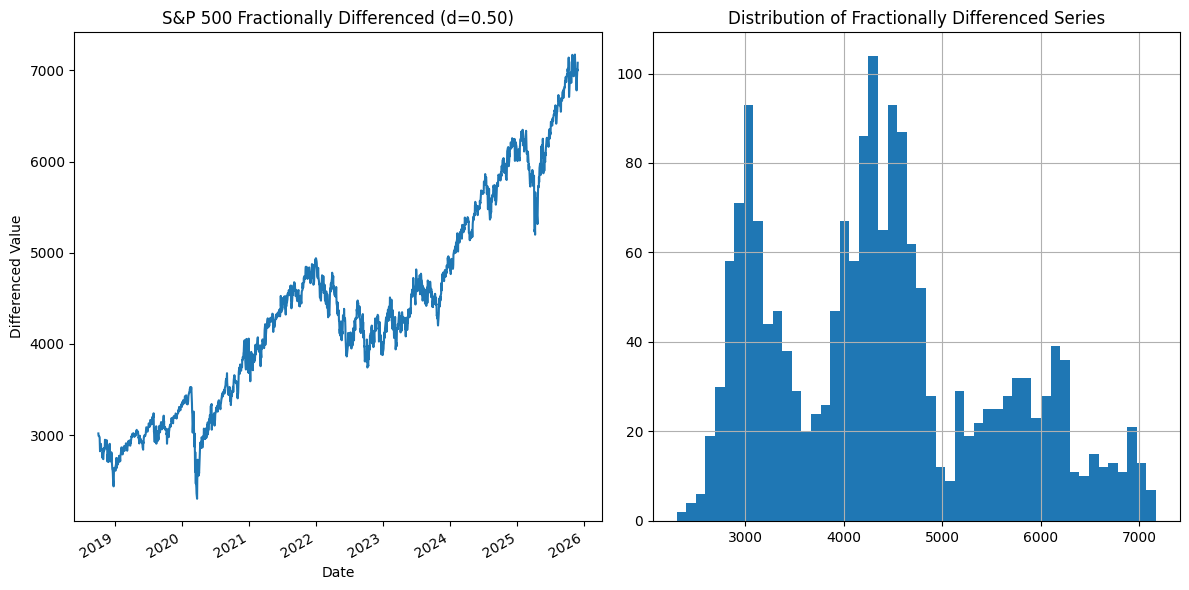

--- ADF Test Results for: Fractional Diff (d=0.50) ---
Test Statistic: 0.1508
P-value: 0.9694
Critical Values:
	1%: -3.4340
	5%: -2.8632
	10%: -2.5676

Conclusion: P-value (0.9694) > 0.05. Fail to reject H0. Series is NON-STATIONARY.
----------------------------------------

===== Step 1 Complete =====

Final DataFrame head (with NaNs from differencing):
Price             Close Log_Returns Frac_Diff
Ticker            ^GSPC                      
Date                                         
2017-12-13  2662.850098         NaN       NaN
2017-12-14  2652.010010   -0.004079       NaN
2017-12-15  2675.810059    0.008934       NaN
2017-12-18  2690.159912    0.005348       NaN
2017-12-19  2681.469971   -0.003235       NaN
2017-12-20  2679.250000   -0.000828       NaN
2017-12-21  2684.570068    0.001984       NaN
2017-12-22  2683.340088   -0.000458       NaN
2017-12-26  2680.500000   -0.001059       NaN
2017-12-27  2682.620117    0.000791       NaN
2017-12-28  2687.540039    0.001832       NaN

In [ ]:
# -----------------------------------------------------------------
# STEP 1.c: Analyze Fractionally Differenced Series
# -----------------------------------------------------------------
print("===== Starting Step 1.c: Fractional Differencing =====")
# This step fulfills the requirement from

# 1.c - Find the optimal 'd'
# We want the smallest 'd' that makes the series stationary (p-value < 0.05)
print("Finding optimal 'd' (this may take a moment)...")

X = data['Close']
optimal_d = 0
found_d = False

for d in np.arange(0.1, 1.01, 0.02): # Step by 0.02 for speed

    fd_series = fractional_diff_ffd(X, d, thresh=1e-4) # Use our custom function

    # Run ADF test
    result = adfuller(fd_series.dropna())
    p_value = result[1]

    print(f"Testing d = {d:.2f}, p-value = {p_value:.4f}")

    if p_value <= 0.05:
        print(f"Found stationary series with d = {d:.2f}")
        optimal_d = d
        found_d = True
        break

if not found_d:
    print("Could not find a 'd' < 1 that makes the series stationary.")
    print("Defaulting to d=0.5 for demonstration.")
    optimal_d = 0.5

# 1.c - Apply the final optimal fractional differencing
data['Frac_Diff'] = fractional_diff_ffd(data['Close'], optimal_d, thresh=1e-4)

# 1.c - Characterization: Summary Statistics
print(f"\n--- Summary Statistics (Fractional Diff, d={optimal_d:.2f}) ---")
print(data['Frac_Diff'].describe())

# 1.c - Characterization: Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
data['Frac_Diff'].plot(title=f'S&P 500 Fractionally Differenced (d={optimal_d:.2f})')
plt.ylabel('Differenced Value')
plt.subplot(1, 2, 2)
data['Frac_Diff'].hist(bins=50)
plt.title('Distribution of Fractionally Differenced Series')
plt.tight_layout()
plt.show()

# 1.c - Characterization: Stationarity (ADF Test)
run_adf_test(data['Frac_Diff'], f'Fractional Diff (d={optimal_d:.2f})')

print("===== Step 1 Complete =====")
print("\nFinal DataFrame head (with NaNs from differencing):")
print(data.head(15)) # Show more to see where data starts
print("\nFinal DataFrame tail:")
print(data.tail())

# Step 2

## 2.a

Preparing Price Levels data...
Training samples: 1592
Test samples: 398

Building and training MLP for Price Levels...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4111 - mae: 0.5042 - val_loss: 0.0292 - val_mae: 0.1417
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1631 - mae: 0.3030 - val_loss: 0.0900 - val_mae: 0.2645
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1430 - mae: 0.2837 - val_loss: 0.0605 - val_mae: 0.2175
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1138 - mae: 0.2615 - val_loss: 0.0537 - val_mae: 0.2057
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0980 - mae: 0.2390 - val_loss: 0.0303 - val_mae: 0.1529
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0940 - mae: 0.2318 - val_loss: 0.0687 - val_mae: 0.2345
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0865 - mae: 0.2190 - val_loss: 0.1361 - val_mae: 0.3318
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0835 - mae: 0.2132 - val_loss: 0.0821 - val_mae: 0.2560
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.077

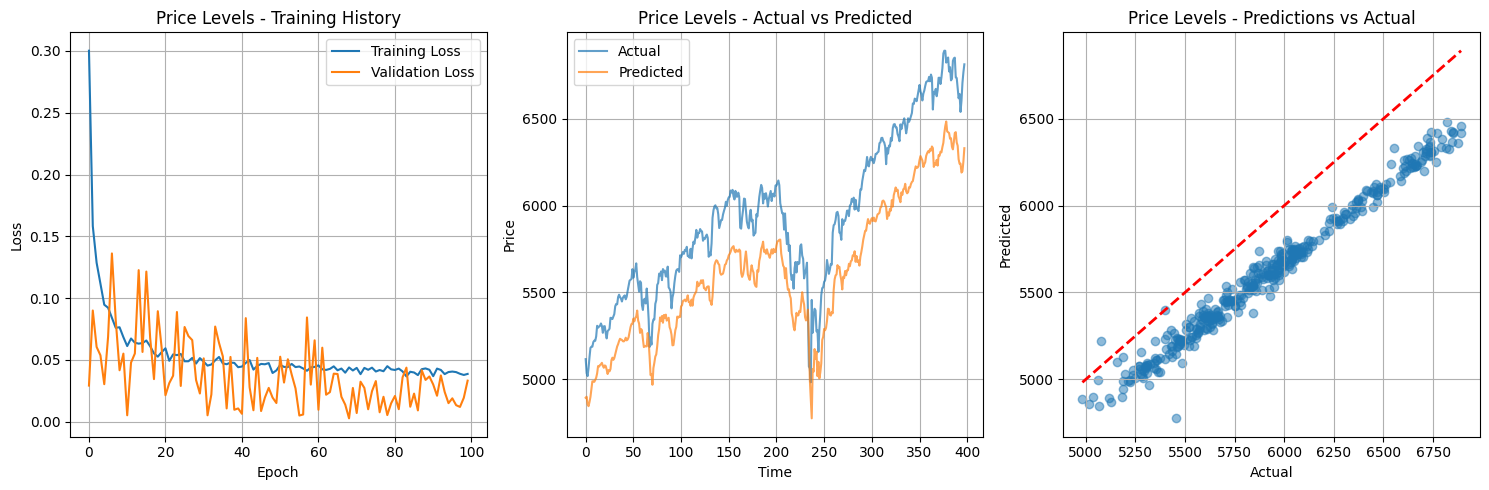


2.a COMPLETED: MLP for Price Levels


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def create_lagged_features(series, n_lags=10):
    """Create lagged features for time series prediction"""
    df = pd.DataFrame(series)
    for i in range(1, n_lags + 1):
        df[f'lag_{i}'] = series.shift(i)
    return df.dropna()

def build_mlp_model(input_dim, hidden_layers=[64, 32, 16], dropout_rate=0.2, learning_rate=0.001):
    """Build MLP model for regression"""
    model = Sequential()

    # Input layer
    model.add(Dense(hidden_layers[0], activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(dropout_rate))

    # Hidden layers
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(dropout_rate))

    # Output layer (regression - single value)
    model.add(Dense(1, activation='linear'))

    # Compile model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

# Parameters
n_lags = 10
test_size = 0.2

# Prepare Price Levels data
print("Preparing Price Levels data...")
levels_data = data['Close'].dropna()
levels_lagged = create_lagged_features(levels_data, n_lags)

# Identify the actual column name of the original series within levels_lagged
# Based on the kernel state, this is '^GSPC'
original_series_col_name = levels_lagged.columns[0]

X_levels = levels_lagged.drop(original_series_col_name, axis=1).values
y_levels = levels_lagged[original_series_col_name].values

# Split data
split_idx = int(len(X_levels) * (1 - test_size))
X_train_levels, X_test_levels = X_levels[:split_idx], X_levels[split_idx:]
y_train_levels, y_test_levels = y_levels[:split_idx], y_levels[split_idx:]

# Scale features and target
scaler_X_levels = StandardScaler()
scaler_y_levels = StandardScaler()

X_train_levels_scaled = scaler_X_levels.fit_transform(X_train_levels)
X_test_levels_scaled = scaler_X_levels.transform(X_test_levels)
y_train_levels_scaled = scaler_y_levels.fit_transform(y_train_levels.reshape(-1, 1)).flatten()
y_test_levels_scaled = scaler_y_levels.transform(y_test_levels.reshape(-1, 1)).flatten()

print(f"Training samples: {X_train_levels_scaled.shape[0]}")
print(f"Test samples: {X_test_levels_scaled.shape[0]}")

# Build and train model
print("\nBuilding and training MLP for Price Levels...")
model_levels = build_mlp_model(input_dim=X_train_levels_scaled.shape[1])
model_levels.summary()

# Train the model
history_levels = model_levels.fit(
    X_train_levels_scaled, y_train_levels_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Make predictions
y_pred_levels_scaled = model_levels.predict(X_test_levels_scaled, verbose=0).flatten()
y_pred_levels = scaler_y_levels.inverse_transform(y_pred_levels_scaled.reshape(-1, 1)).flatten()

# Calculate metrics
mse_levels = mean_squared_error(y_test_levels, y_pred_levels)
mae_levels = mean_absolute_error(y_test_levels, y_pred_levels)

print(f"\nPrice Levels Model Results:")
print(f"MSE: {mse_levels:.6f}")
print(f"MAE: {mae_levels:.6f}")

# Plot results
plt.figure(figsize=(15, 5))

# Training history
plt.subplot(1, 3, 1)
plt.plot(history_levels.history['loss'], label='Training Loss')
plt.plot(history_levels.history['val_loss'], label='Validation Loss')
plt.title('Price Levels - Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Predictions vs Actual
plt.subplot(1, 3, 2)
plt.plot(y_test_levels, label='Actual', alpha=0.7)
plt.plot(y_pred_levels, label='Predicted', alpha=0.7)
plt.title('Price Levels - Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Scatter plot
plt.subplot(1, 3, 3)
plt.scatter(y_test_levels, y_pred_levels, alpha=0.5)
plt.plot([y_test_levels.min(), y_test_levels.max()], [y_test_levels.min(), y_test_levels.max()], 'r--', lw=2)
plt.title('Price Levels - Predictions vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)

plt.tight_layout()
plt.show()

# Store results for later comparison
results_levels = {
    'model': 'Price Levels',
    'mse': mse_levels,
    'mae': mae_levels,
    'predictions': y_pred_levels,
    'actual': y_test_levels,
    'model_object': model_levels
}

print("\n" + "="*50)
print("2.a COMPLETED: MLP for Price Levels")
print("="*50)

## 2.b


STEP 2.b: MLP FOR STATIONARY SERIES (LOG RETURNS)
Preparing Log Returns data...
Training samples: 1591
Test samples: 398

Building and training MLP for Log Returns...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0618 - mae: 0.1529 - val_loss: 9.7779e-04 - val_mae: 0.0230
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0133 - mae: 0.0704 - val_loss: 4.3643e-04 - val_mae: 0.0160
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0064 - mae: 0.0506 - val_loss: 3.6129e-04 - val_mae: 0.0148
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0059 - mae: 0.0444 - val_loss: 2.5599e-04 - val_mae: 0.0124
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - mae: 0.0333 - val_loss: 1.3892e-04 - val_mae: 0.0089
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037 - mae: 0.0294 - val_loss: 1.3812e-04 - val_mae: 0.0091
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015 - mae: 0.0235 - val_loss: 9.8237e-05 - val_mae: 0.0078
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016 - mae: 0.0221 - val_loss: 8.8487e-05 - val_mae: 0.0074
Epoch 9/100
40/40 ━━━━━━━━━━━━━

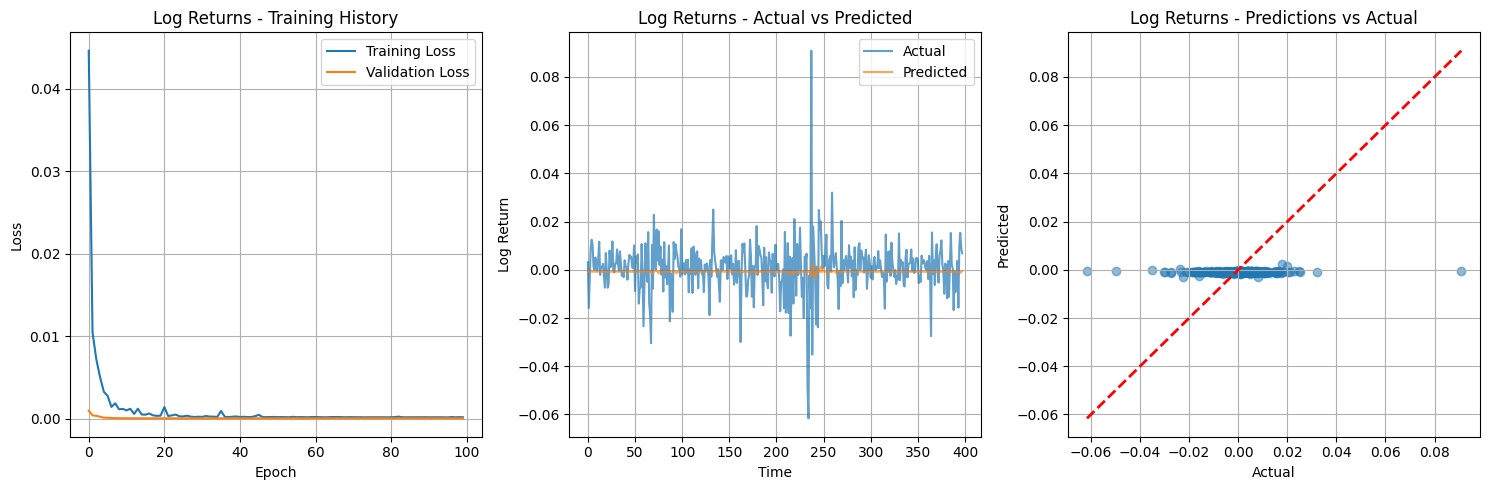


2.b COMPLETED: MLP for Log Returns


In [ ]:
# -----------------------------------------------------------------
# STEP 2.b: MLP for Stationary Series (Log Returns)
# -----------------------------------------------------------------

print("\n" + "="*60)
print("STEP 2.b: MLP FOR STATIONARY SERIES (LOG RETURNS)")
print("="*60)

# Prepare Log Returns data
print("Preparing Log Returns data...")
returns_data = data['Log_Returns'].dropna()
returns_lagged = create_lagged_features(returns_data, n_lags)
X_returns = returns_lagged.drop('Log_Returns', axis=1).values
y_returns = returns_lagged['Log_Returns'].values

# Split data
split_idx = int(len(X_returns) * (1 - test_size))
X_train_returns, X_test_returns = X_returns[:split_idx], X_returns[split_idx:]
y_train_returns, y_test_returns = y_returns[:split_idx], y_returns[split_idx:]

# Scale features (returns are already stationary, no need to scale target)
scaler_X_returns = StandardScaler()
X_train_returns_scaled = scaler_X_returns.fit_transform(X_train_returns)
X_test_returns_scaled = scaler_X_returns.transform(X_test_returns)

print(f"Training samples: {X_train_returns_scaled.shape[0]}")
print(f"Test samples: {X_test_returns_scaled.shape[0]}")

# Build and train model
print("\nBuilding and training MLP for Log Returns...")
model_returns = build_mlp_model(input_dim=X_train_returns_scaled.shape[1])
model_returns.summary()

# Train the model
history_returns = model_returns.fit(
    X_train_returns_scaled, y_train_returns,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Make predictions
y_pred_returns = model_returns.predict(X_test_returns_scaled, verbose=0).flatten()

# Calculate metrics
mse_returns = mean_squared_error(y_test_returns, y_pred_returns)
mae_returns = mean_absolute_error(y_test_returns, y_pred_returns)

print(f"\nLog Returns Model Results:")
print(f"MSE: {mse_returns:.6f}")
print(f"MAE: {mae_returns:.6f}")

# Plot results
plt.figure(figsize=(15, 5))

# Training history
plt.subplot(1, 3, 1)
plt.plot(history_returns.history['loss'], label='Training Loss')
plt.plot(history_returns.history['val_loss'], label='Validation Loss')
plt.title('Log Returns - Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Predictions vs Actual
plt.subplot(1, 3, 2)
plt.plot(y_test_returns, label='Actual', alpha=0.7)
plt.plot(y_pred_returns, label='Predicted', alpha=0.7)
plt.title('Log Returns - Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)

# Scatter plot
plt.subplot(1, 3, 3)
plt.scatter(y_test_returns, y_pred_returns, alpha=0.5)
plt.plot([y_test_returns.min(), y_test_returns.max()], [y_test_returns.min(), y_test_returns.max()], 'r--', lw=2)
plt.title('Log Returns - Predictions vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)

plt.tight_layout()
plt.show()

# Store results for later comparison
results_returns = {
    'model': 'Log Returns',
    'mse': mse_returns,
    'mae': mae_returns,
    'predictions': y_pred_returns,
    'actual': y_test_returns,
    'model_object': model_returns
}

print("\n" + "="*50)
print("2.b COMPLETED: MLP for Log Returns")
print("="*50)

2.c


STEP 2.c: MLP FOR FRACTIONALLY DIFFERENCED SERIES
Preparing Fractionally Differenced data...
Training samples: 849
Test samples: 213

Building and training MLP for Fractionally Differenced Series...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.2690 - mae: 0.3806 - val_loss: 2.8424 - val_mae: 1.6368
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1320 - mae: 0.2610 - val_loss: 1.1410 - val_mae: 1.0310
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0782 - mae: 0.2053 - val_loss: 0.0521 - val_mae: 0.1985
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0704 - mae: 0.1970 - val_loss: 0.0645 - val_mae: 0.2245
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0676 - mae: 0.1950 - val_loss: 0.0632 - val_mae: 0.2234
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0676 - mae: 0.1937 - val_loss: 0.0626 - val_mae: 0.2233
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0661 - mae: 0.1921 - val_loss: 0.0596 - val_mae: 0.2178
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0557 - mae: 0.1738 - val_loss: 0.0428 - val_mae: 0.1812
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.05

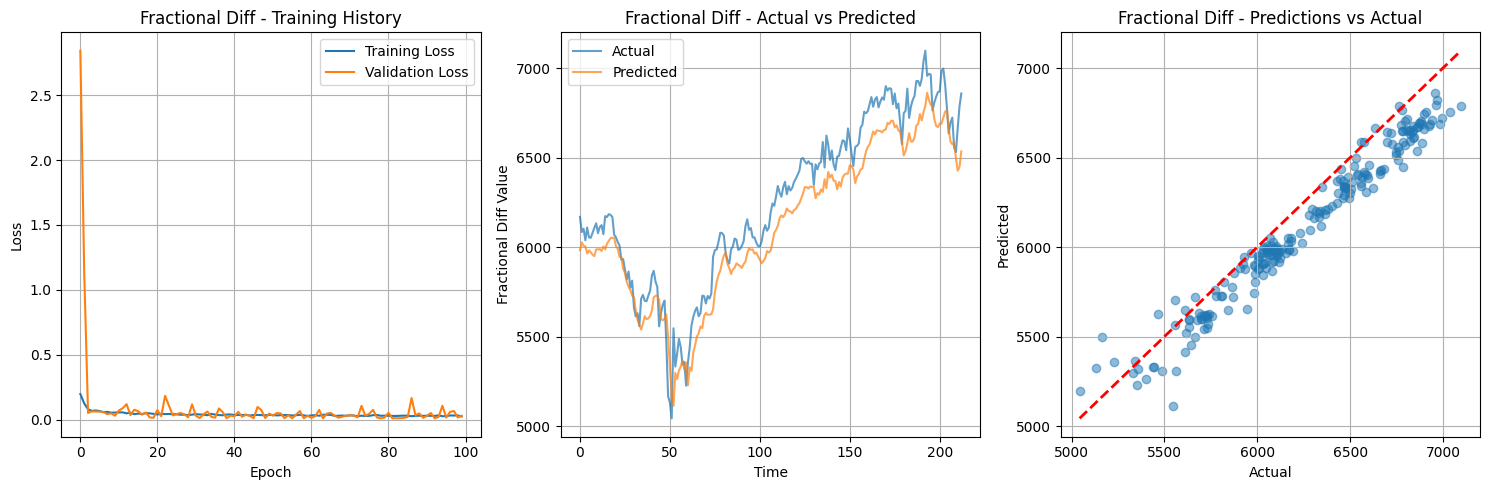


2.c COMPLETED: MLP for Fractionally Differenced Series


In [ ]:
# -----------------------------------------------------------------
# STEP 2.c: MLP for Fractionally Differenced Series
# -----------------------------------------------------------------

print("\n" + "="*60)
print("STEP 2.c: MLP FOR FRACTIONALLY DIFFERENCED SERIES")
print("="*60)

# Prepare Fractionally Differenced data
print("Preparing Fractionally Differenced data...")
d = 0.5  # Fractional differencing parameter
frac_diff_data = fractional_diff_ffd(data['Close'], d).dropna()

frac_diff_lagged = create_lagged_features(frac_diff_data, n_lags)
# Get the actual column name of the original series within frac_diff_lagged
original_frac_col_name = frac_diff_lagged.columns[0]
X_frac = frac_diff_lagged.drop(original_frac_col_name, axis=1).values
y_frac = frac_diff_lagged[original_frac_col_name].values

# Split data
split_idx = int(len(X_frac) * (1 - test_size))
X_train_frac, X_test_frac = X_frac[:split_idx], X_frac[split_idx:]
y_train_frac, y_test_frac = y_frac[:split_idx], y_frac[split_idx:]

# Scale features and target
scaler_X_frac = StandardScaler()
scaler_y_frac = StandardScaler()

X_train_frac_scaled = scaler_X_frac.fit_transform(X_train_frac)
X_test_frac_scaled = scaler_X_frac.transform(X_test_frac)
y_train_frac_scaled = scaler_y_frac.fit_transform(y_train_frac.reshape(-1, 1)).flatten()
y_test_frac_scaled = scaler_y_frac.transform(y_test_frac.reshape(-1, 1)).flatten()

print(f"Training samples: {X_train_frac_scaled.shape[0]}")
print(f"Test samples: {X_test_frac_scaled.shape[0]}")

# Build and train model
print("\nBuilding and training MLP for Fractionally Differenced Series...")
model_frac = build_mlp_model(input_dim=X_train_frac_scaled.shape[1])
model_frac.summary()

# Train the model
history_frac = model_frac.fit(
    X_train_frac_scaled, y_train_frac_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Make predictions
y_pred_frac_scaled = model_frac.predict(X_test_frac_scaled, verbose=0).flatten()
y_pred_frac = scaler_y_frac.inverse_transform(y_pred_frac_scaled.reshape(-1, 1)).flatten()

# Calculate metrics
mse_frac = mean_squared_error(y_test_frac, y_pred_frac)
mae_frac = mean_absolute_error(y_test_frac, y_pred_frac)

print(f"\nFractionally Differenced Model Results:")
print(f"MSE: {mse_frac:.6f}")
print(f"MAE: {mae_frac:.6f}")

# Plot results
plt.figure(figsize=(15, 5))

# Training history
plt.subplot(1, 3, 1)
plt.plot(history_frac.history['loss'], label='Training Loss')
plt.plot(history_frac.history['val_loss'], label='Validation Loss')
plt.title('Fractional Diff - Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Predictions vs Actual
plt.subplot(1, 3, 2)
plt.plot(y_test_frac, label='Actual', alpha=0.7)
plt.plot(y_pred_frac, label='Predicted', alpha=0.7)
plt.title('Fractional Diff - Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Fractional Diff Value')
plt.legend()
plt.grid(True)

# Scatter plot
plt.subplot(1, 3, 3)
plt.scatter(y_test_frac, y_pred_frac, alpha=0.5)
plt.plot([y_test_frac.min(), y_test_frac.max()], [y_test_frac.min(), y_test_frac.max()], 'r--', lw=2)
plt.title('Fractional Diff - Predictions vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)

plt.tight_layout()
plt.show()

# Store results for later comparison
results_frac = {
    'model': 'Fractional Diff',
    'mse': mse_frac,
    'mae': mae_frac,
    'predictions': y_pred_frac,
    'actual': y_test_frac,
    'model_object': model_frac
}

print("\n" + "="*50)
print("2.c COMPLETED: MLP for Fractionally Differenced Series")
print("="*50)

## 2.d


STEP 2.d: MODEL COMPARISON AND EVALUATION

--- PERFORMANCE COMPARISON ---
             Model            MSE         MAE
0     Price Levels  102322.587619  309.306957
1      Log Returns       0.000116    0.007119
2  Fractional Diff   26047.928328  142.599103

🏆 BEST MODEL BY MSE: Log Returns (MSE: 0.000116)
🏆 BEST MODEL BY MAE: Log Returns (MAE: 0.007119)

--- RELATIVE PERFORMANCE IMPROVEMENT vs PRICE LEVELS MODEL ---
             Model  MSE Improvement %  MAE Improvement %
0      Log Returns         100.000000          99.997698
1  Fractional Diff          74.543325          53.897221


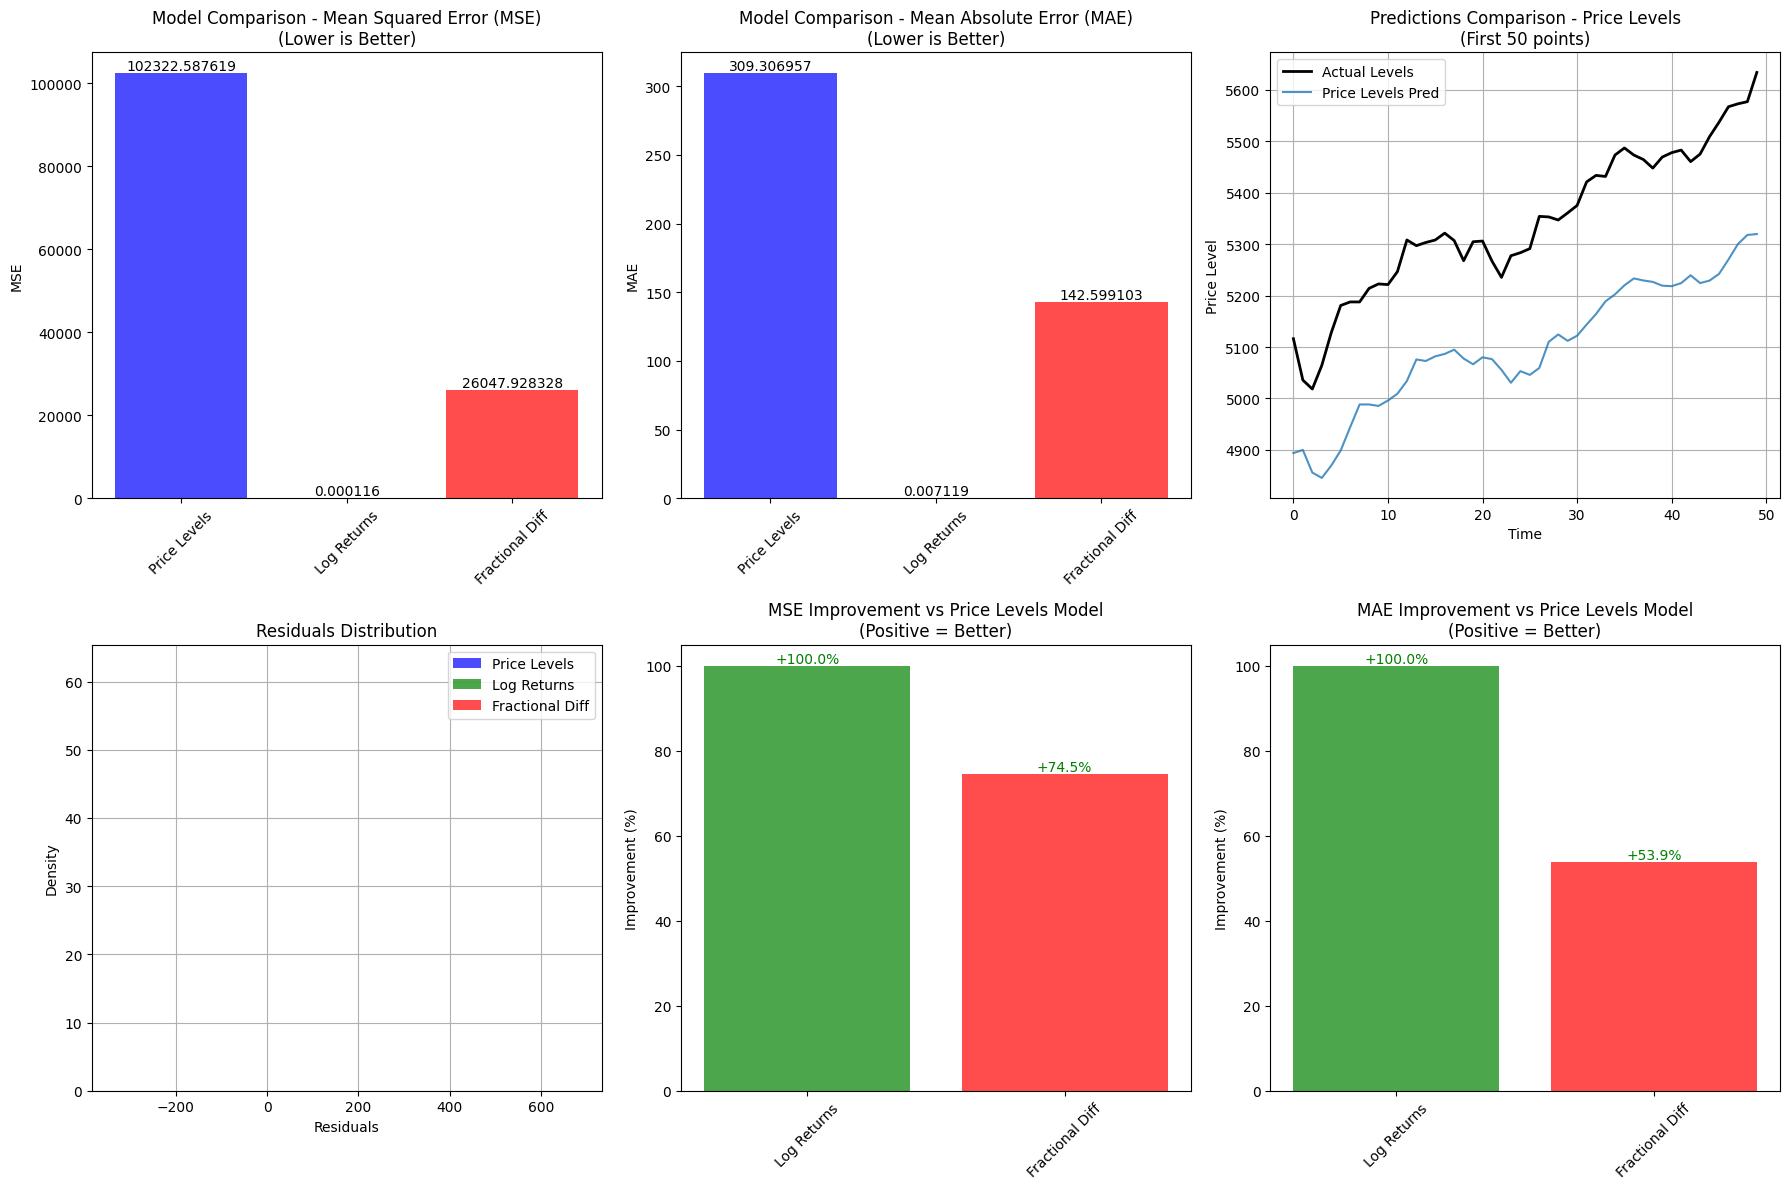


STEP 2 COMPLETED: All MLP Models Built and Evaluated


In [ ]:
# -----------------------------------------------------------------
# STEP 2.d: MODEL COMPARISON AND EVALUATION
# -----------------------------------------------------------------

print("\n" + "="*60)
print("STEP 2.d: MODEL COMPARISON AND EVALUATION")
print("="*60)

# Combine all results
all_results = [results_levels, results_returns, results_frac]

# Create comparison table
comparison_data = []
for result in all_results:
    comparison_data.append({
        'Model': result['model'],
        'MSE': result['mse'],
        'MAE': result['mae']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n--- PERFORMANCE COMPARISON ---")
print(comparison_df)

# Find best models
best_mse_model = comparison_df.loc[comparison_df['MSE'].idxmin()]
best_mae_model = comparison_df.loc[comparison_df['MAE'].idxmin()]

print(f"\n🏆 BEST MODEL BY MSE: {best_mse_model['Model']} (MSE: {best_mse_model['MSE']:.6f})")
print(f"🏆 BEST MODEL BY MAE: {best_mae_model['Model']} (MAE: {best_mae_model['MAE']:.6f})")

# Comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Performance metrics comparison
models = comparison_df['Model']
mse_values = comparison_df['MSE']
mae_values = comparison_df['MAE']

axes[0, 0].bar(models, mse_values, color=['blue', 'green', 'red'], alpha=0.7)
axes[0, 0].set_title('Model Comparison - Mean Squared Error (MSE)\n(Lower is Better)')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(mse_values):
    axes[0, 0].text(i, v, f'{v:.6f}', ha='center', va='bottom')

axes[0, 1].bar(models, mae_values, color=['blue', 'green', 'red'], alpha=0.7)
axes[0, 1].set_title('Model Comparison - Mean Absolute Error (MAE)\n(Lower is Better)')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(mae_values):
    axes[0, 1].text(i, v, f'{v:.6f}', ha='center', va='bottom')

# 2. Predictions comparison (first 50 points for clarity)
axes[0, 2].plot(results_levels['actual'][:50], label='Actual Levels', linewidth=2, color='black')
axes[0, 2].plot(results_levels['predictions'][:50], label='Price Levels Pred', alpha=0.8)
axes[0, 2].set_title('Predictions Comparison - Price Levels\n(First 50 points)')
axes[0, 2].set_xlabel('Time')
axes[0, 2].set_ylabel('Price Level')
axes[0, 2].legend()
axes[0, 2].grid(True)

# 3. Residuals analysis
residuals_levels = results_levels['actual'] - results_levels['predictions']
residuals_returns = results_returns['actual'] - results_returns['predictions']
residuals_frac = results_frac['actual'] - results_frac['predictions']

axes[1, 0].hist(residuals_levels, bins=30, alpha=0.7, label='Price Levels', density=True, color='blue')
axes[1, 0].hist(residuals_returns, bins=30, alpha=0.7, label='Log Returns', density=True, color='green')
axes[1, 0].hist(residuals_frac, bins=30, alpha=0.7, label='Fractional Diff', density=True, color='red')
axes[1, 0].set_title('Residuals Distribution')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 4. Relative performance improvement
mse_baseline = results_levels['mse']
mae_baseline = results_levels['mae']

improvement_data = []
for result in [results_returns, results_frac]:
    mse_imp = ((mse_baseline - result['mse']) / mse_baseline) * 100
    mae_imp = ((mae_baseline - result['mae']) / mae_baseline) * 100
    improvement_data.append({
        'Model': result['model'],
        'MSE Improvement %': mse_imp,
        'MAE Improvement %': mae_imp
    })

improvement_df = pd.DataFrame(improvement_data)
print("\n--- RELATIVE PERFORMANCE IMPROVEMENT vs PRICE LEVELS MODEL ---")
print(improvement_df)

models_imp = improvement_df['Model']
mse_imp_values = improvement_df['MSE Improvement %']
mae_imp_values = improvement_df['MAE Improvement %']

axes[1, 1].bar(models_imp, mse_imp_values, color=['green', 'red'], alpha=0.7)
axes[1, 1].set_title('MSE Improvement vs Price Levels Model\n(Positive = Better)')
axes[1, 1].set_ylabel('Improvement (%)')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(mse_imp_values):
    color = 'green' if v > 0 else 'red'
    axes[1, 1].text(i, v, f'{v:+.1f}%', ha='center', va='bottom' if v > 0 else 'top', color=color)

axes[1, 2].bar(models_imp, mae_imp_values, color=['green', 'red'], alpha=0.7)
axes[1, 2].set_title('MAE Improvement vs Price Levels Model\n(Positive = Better)')
axes[1, 2].set_ylabel('Improvement (%)')
axes[1, 2].tick_params(axis='x', rotation=45)
for i, v in enumerate(mae_imp_values):
    color = 'green' if v > 0 else 'red'
    axes[1, 2].text(i, v, f'{v:+.1f}%', ha='center', va='bottom' if v > 0 else 'top', color=color)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("STEP 2 COMPLETED: All MLP Models Built and Evaluated")
print("="*60)

# Step 3

In [ ]:
!pip install pyts scikit-image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from pyts.image import GramianAngularField
from skimage.transform import resize
import warnings
warnings.filterwarnings('ignore')

## 3.a


STEP 3.a: CNN WITH GAF FOR PRICE LEVELS
Preparing Price Levels data for GAF-CNN...
Created 1950 rolling windows
GAF images shape: (1950, 28, 28, 1)
Training samples: 1560
Test samples: 390

Building and training CNN with GAF for Price Levels...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,401 (462.50 KB)

 Trainable params: 117,953 (460.75 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - loss: 2.1119 - mae: 1.1439 - val_loss: 1.7645 - val_mae: 1.2254
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.9212 - mae: 0.8018 - val_loss: 2.3240 - val_mae: 1.4321
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.7620 - mae: 0.7373 - val_loss: 2.1617 - val_mae: 1.3712
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.7314 - mae: 0.7323 - val_loss: 1.6695 - val_mae: 1.1876
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.6954 - mae: 0.7094 - val_loss: 1.7074 - val_mae: 1.2063
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.6339 - mae: 0.6805 - val_loss: 1.9211 - val_mae: 1.2907
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.5750 - mae: 0.6377 - val_loss: 1.7278 - val_mae: 1.2145
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.5696 - mae: 0.6405 - val_loss: 2.2669 - val_mae: 1.3968
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.


GAF-CNN Price Levels Model Results:
MSE: 5821439.277053
MAE: 2354.028117


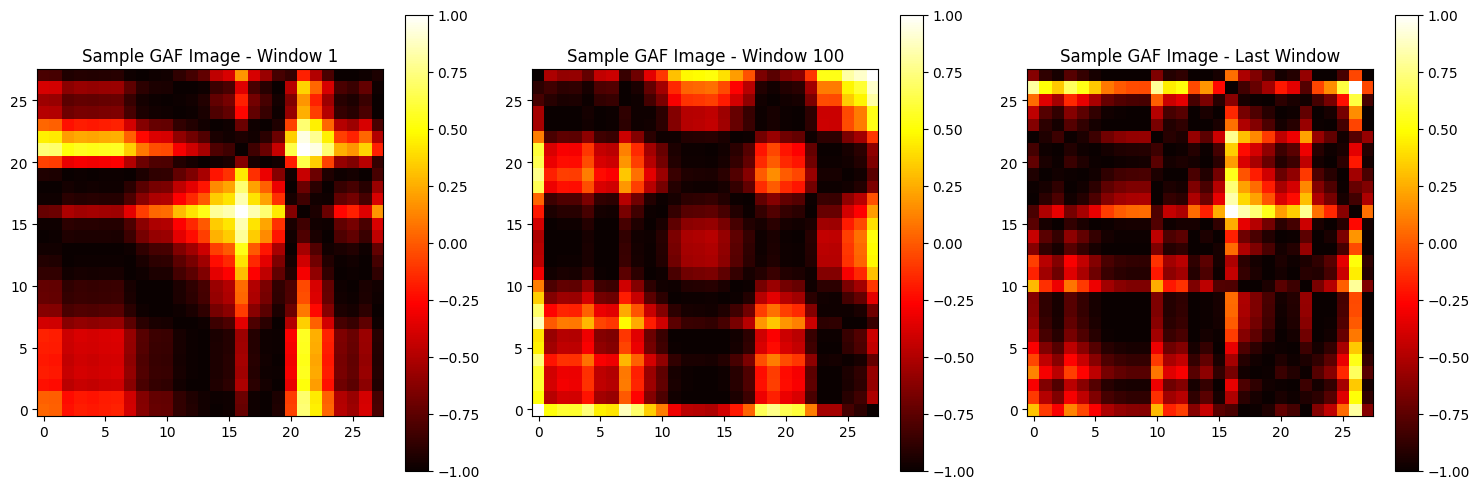

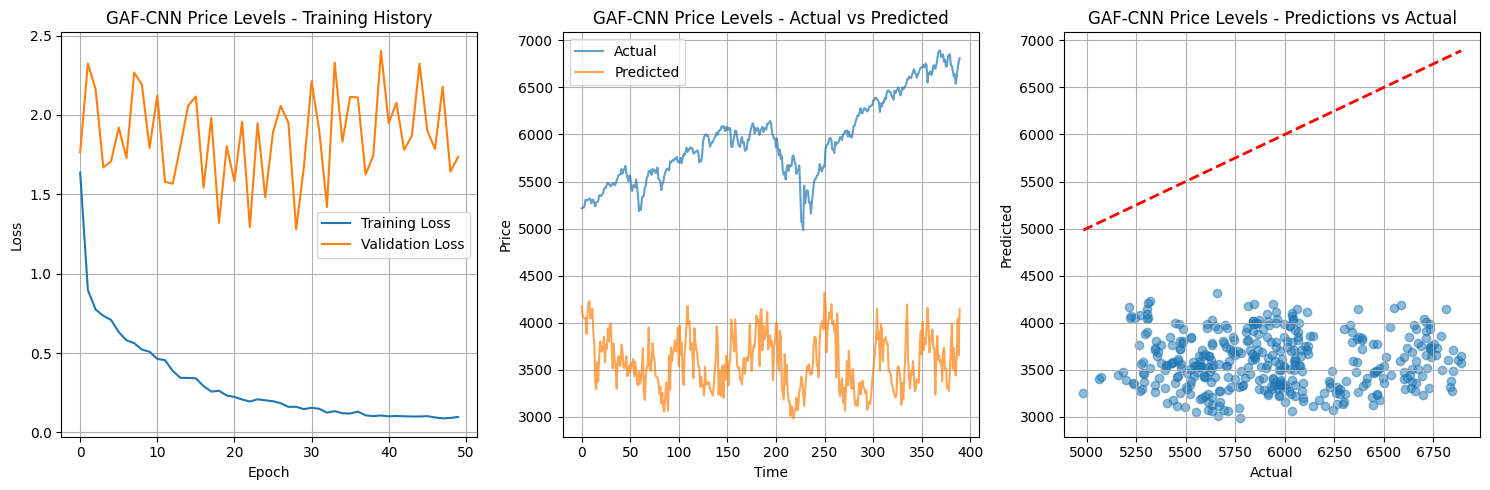


3.a COMPLETED: CNN with GAF for Price Levels


In [ ]:
# -----------------------------------------------------------------
# STEP 3.a: CNN with GAF for Price Levels
# -----------------------------------------------------------------

print("\n" + "="*60)
print("STEP 3.a: CNN WITH GAF FOR PRICE LEVELS")
print("="*60)

def create_gaf_images(series, image_size=28, method='summation'):
    """Create Gramian Angular Field images from time series"""
    # Reshape series for pyts
    series_2d = series.reshape(1, -1)

    # Create GAF transformer
    gaf = GramianAngularField(image_size=image_size, method=method)

    # Transform to GAF images
    gaf_images = gaf.fit_transform(series_2d)

    return gaf_images[0]  # Return first (and only) image

def create_rolling_windows(series, window_size, prediction_horizon=1):
    """Create rolling windows for time series prediction"""
    X, y = [], []
    for i in range(len(series) - window_size - prediction_horizon + 1):
        X.append(series[i:(i + window_size)])
        y.append(series[i + window_size + prediction_horizon - 1])
    return np.array(X), np.array(y)

def build_cnn_model(input_shape, learning_rate=0.001):
    """Build CNN model for regression"""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='linear')
    ])

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                 loss='mse',
                 metrics=['mae'])

    return model

# Parameters
window_size = 50  # Size of rolling window for GAF
image_size = 28   # Size of GAF image
test_size = 0.2
prediction_horizon = 1

print("Preparing Price Levels data for GAF-CNN...")

# Use price levels data
levels_data = data['Close'].dropna().values

# Create rolling windows
X_windows, y_levels = create_rolling_windows(levels_data, window_size, prediction_horizon)

print(f"Created {len(X_windows)} rolling windows")

# Create GAF images for each window
X_gaf = []
for i, window in enumerate(X_windows):
    gaf_image = create_gaf_images(window, image_size=image_size)
    X_gaf.append(gaf_image)

X_gaf = np.array(X_gaf)
X_gaf = X_gaf.reshape(X_gaf.shape[0], image_size, image_size, 1)  # Add channel dimension

print(f"GAF images shape: {X_gaf.shape}")

# Split data
split_idx = int(len(X_gaf) * (1 - test_size))
X_train_gaf, X_test_gaf = X_gaf[:split_idx], X_gaf[split_idx:]
y_train_levels, y_test_levels = y_levels[:split_idx], y_levels[split_idx:]

# Scale target
scaler_y_levels = StandardScaler()
y_train_levels_scaled = scaler_y_levels.fit_transform(y_train_levels.reshape(-1, 1)).flatten()
y_test_levels_scaled = scaler_y_levels.transform(y_test_levels.reshape(-1, 1)).flatten()

print(f"Training samples: {X_train_gaf.shape[0]}")
print(f"Test samples: {X_test_gaf.shape[0]}")

# Build and train CNN model
print("\nBuilding and training CNN with GAF for Price Levels...")
model_gaf_levels = build_cnn_model(input_shape=(image_size, image_size, 1))
model_gaf_levels.summary()

# Train the model
history_gaf_levels = model_gaf_levels.fit(
    X_train_gaf, y_train_levels_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Make predictions
y_pred_gaf_levels_scaled = model_gaf_levels.predict(X_test_gaf, verbose=0).flatten()
y_pred_gaf_levels = scaler_y_levels.inverse_transform(y_pred_gaf_levels_scaled.reshape(-1, 1)).flatten()

# Calculate metrics
mse_gaf_levels = mean_squared_error(y_test_levels, y_pred_gaf_levels)
mae_gaf_levels = mean_absolute_error(y_test_levels, y_pred_gaf_levels)

print(f"\nGAF-CNN Price Levels Model Results:")
print(f"MSE: {mse_gaf_levels:.6f}")
print(f"MAE: {mae_gaf_levels:.6f}")

# Plot sample GAF images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(X_gaf[0, :, :, 0], cmap='hot', origin='lower')
plt.title('Sample GAF Image - Window 1')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(X_gaf[100, :, :, 0], cmap='hot', origin='lower')
plt.title('Sample GAF Image - Window 100')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(X_gaf[-1, :, :, 0], cmap='hot', origin='lower')
plt.title('Sample GAF Image - Last Window')
plt.colorbar()

plt.tight_layout()
plt.show()

# Plot results
plt.figure(figsize=(15, 5))

# Training history
plt.subplot(1, 3, 1)
plt.plot(history_gaf_levels.history['loss'], label='Training Loss')
plt.plot(history_gaf_levels.history['val_loss'], label='Validation Loss')
plt.title('GAF-CNN Price Levels - Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Predictions vs Actual
plt.subplot(1, 3, 2)
plt.plot(y_test_levels, label='Actual', alpha=0.7)
plt.plot(y_pred_gaf_levels, label='Predicted', alpha=0.7)
plt.title('GAF-CNN Price Levels - Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Scatter plot
plt.subplot(1, 3, 3)
plt.scatter(y_test_levels, y_pred_gaf_levels, alpha=0.5)
plt.plot([y_test_levels.min(), y_test_levels.max()], [y_test_levels.min(), y_test_levels.max()], 'r--', lw=2)
plt.title('GAF-CNN Price Levels - Predictions vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)

plt.tight_layout()
plt.show()

# Store results for later comparison
results_gaf_levels = {
    'model': 'GAF-CNN Price Levels',
    'mse': mse_gaf_levels,
    'mae': mae_gaf_levels,
    'predictions': y_pred_gaf_levels,
    'actual': y_test_levels,
    'model_object': model_gaf_levels
}

print("\n" + "="*50)
print("3.a COMPLETED: CNN with GAF for Price Levels")
print("="*50)

## 3.b


STEP 3.b: CNN WITH GAF FOR STATIONARY SERIES (LOG RETURNS)
Preparing Log Returns data for GAF-CNN...
Created 1949 rolling windows
GAF images shape: (1949, 28, 28, 1)
Training samples: 1559
Test samples: 390

Building and training CNN with GAF for Log Returns...


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,401 (462.50 KB)

 Trainable params: 117,953 (460.75 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - loss: 1.9823 - mae: 1.0382 - val_loss: 0.0179 - val_mae: 0.1325
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.2830 - mae: 0.3920 - val_loss: 0.0165 - val_mae: 0.1269
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.1205 - mae: 0.2570 - val_loss: 0.0277 - val_mae: 0.1652
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0758 - mae: 0.2081 - val_loss: 0.0245 - val_mae: 0.1525
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0443 - mae: 0.1566 - val_loss: 0.0584 - val_mae: 0.2368
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0286 - mae: 0.1270 - val_loss: 0.0313 - val_mae: 0.1689
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0240 - mae: 0.1099 - val_loss: 0.0197 - val_mae: 0.1278
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0160 - mae: 0.0922 - val_loss: 0.0297 - val_mae: 0.1560
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.01

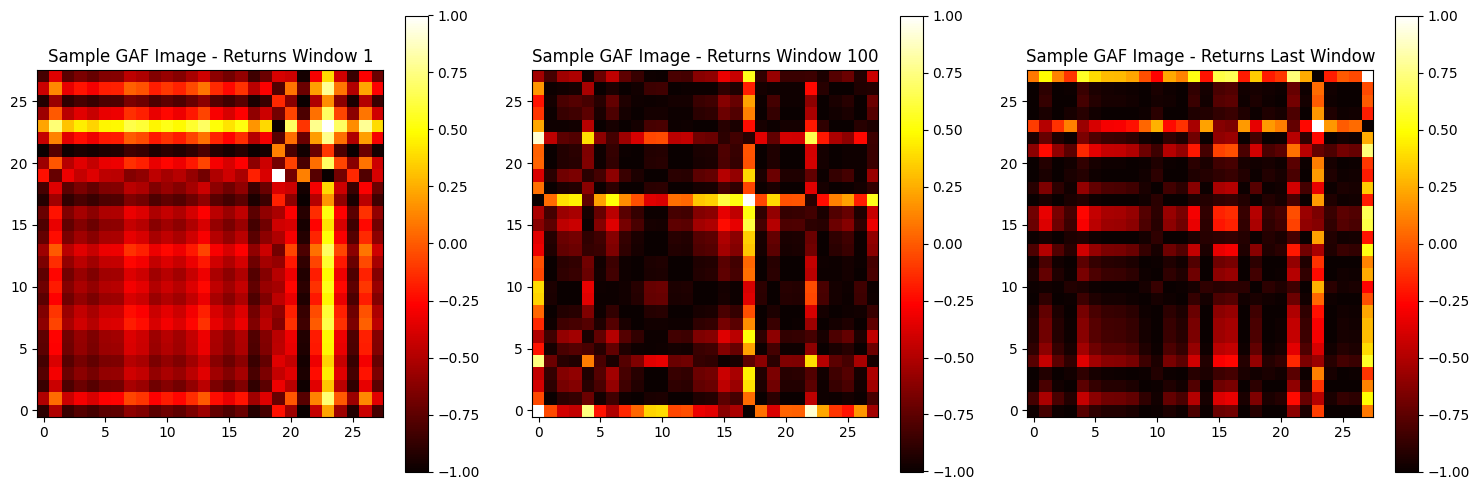

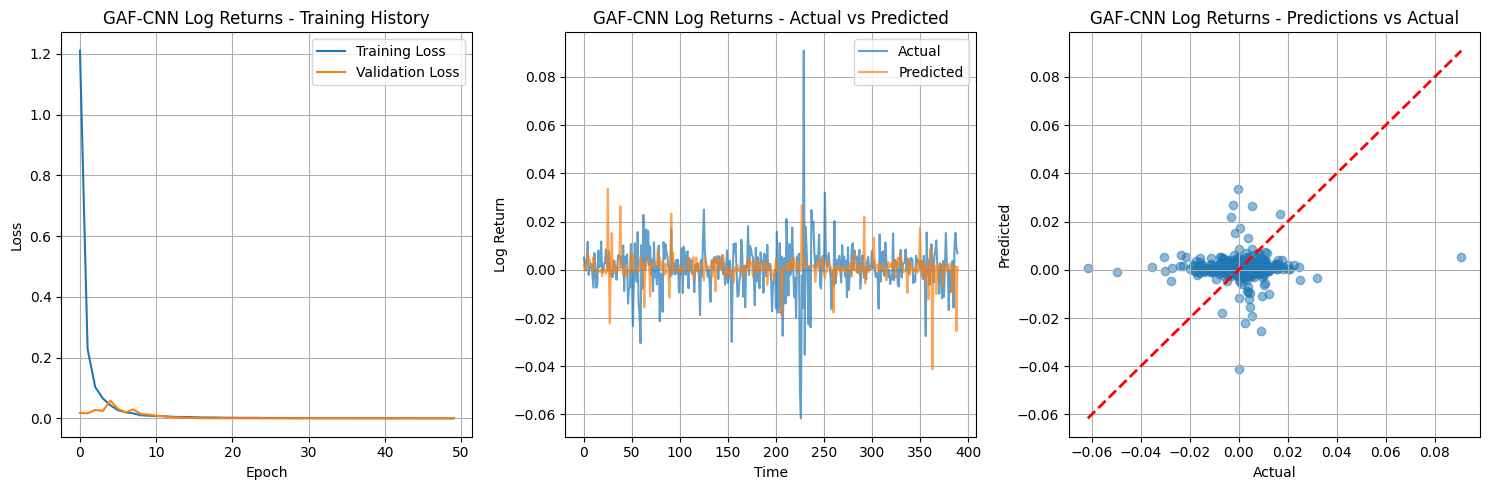


3.b COMPLETED: CNN with GAF for Log Returns


In [ ]:
# -----------------------------------------------------------------
# STEP 3.b: CNN WITH GAF FOR STATIONARY SERIES (LOG RETURNS)
# -----------------------------------------------------------------

print("\n" + "="*60)
print("STEP 3.b: CNN WITH GAF FOR STATIONARY SERIES (LOG RETURNS)")
print("="*60)

print("Preparing Log Returns data for GAF-CNN...")

# Use log returns data
returns_data = data['Log_Returns'].dropna().values

# Create rolling windows
X_returns_windows, y_returns = create_rolling_windows(returns_data, window_size, prediction_horizon)

print(f"Created {len(X_returns_windows)} rolling windows")

# Create GAF images for each window
X_returns_gaf = []
for i, window in enumerate(X_returns_windows):
    gaf_image = create_gaf_images(window, image_size=image_size)
    X_returns_gaf.append(gaf_image)

X_returns_gaf = np.array(X_returns_gaf)
X_returns_gaf = X_returns_gaf.reshape(X_returns_gaf.shape[0], image_size, image_size, 1)

print(f"GAF images shape: {X_returns_gaf.shape}")

# Split data
split_idx = int(len(X_returns_gaf) * (1 - test_size))
X_train_returns_gaf, X_test_returns_gaf = X_returns_gaf[:split_idx], X_returns_gaf[split_idx:]
y_train_returns, y_test_returns = y_returns[:split_idx], y_returns[split_idx:]

print(f"Training samples: {X_train_returns_gaf.shape[0]}")
print(f"Test samples: {X_test_returns_gaf.shape[0]}")

# Build and train CNN model
print("\nBuilding and training CNN with GAF for Log Returns...")
model_gaf_returns = build_cnn_model(input_shape=(image_size, image_size, 1))
model_gaf_returns.summary()

# Train the model
history_gaf_returns = model_gaf_returns.fit(
    X_train_returns_gaf, y_train_returns,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Make predictions
y_pred_gaf_returns = model_gaf_returns.predict(X_test_returns_gaf, verbose=0).flatten()

# Calculate metrics
mse_gaf_returns = mean_squared_error(y_test_returns, y_pred_gaf_returns)
mae_gaf_returns = mean_absolute_error(y_test_returns, y_pred_gaf_returns)

print(f"\nGAF-CNN Log Returns Model Results:")
print(f"MSE: {mse_gaf_returns:.6f}")
print(f"MAE: {mae_gaf_returns:.6f}")

# Plot sample GAF images for returns
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(X_returns_gaf[0, :, :, 0], cmap='hot', origin='lower')
plt.title('Sample GAF Image - Returns Window 1')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(X_returns_gaf[100, :, :, 0], cmap='hot', origin='lower')
plt.title('Sample GAF Image - Returns Window 100')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(X_returns_gaf[-1, :, :, 0], cmap='hot', origin='lower')
plt.title('Sample GAF Image - Returns Last Window')
plt.colorbar()

plt.tight_layout()
plt.show()

# Plot results
plt.figure(figsize=(15, 5))

# Training history
plt.subplot(1, 3, 1)
plt.plot(history_gaf_returns.history['loss'], label='Training Loss')
plt.plot(history_gaf_returns.history['val_loss'], label='Validation Loss')
plt.title('GAF-CNN Log Returns - Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Predictions vs Actual
plt.subplot(1, 3, 2)
plt.plot(y_test_returns, label='Actual', alpha=0.7)
plt.plot(y_pred_gaf_returns, label='Predicted', alpha=0.7)
plt.title('GAF-CNN Log Returns - Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)

# Scatter plot
plt.subplot(1, 3, 3)
plt.scatter(y_test_returns, y_pred_gaf_returns, alpha=0.5)
plt.plot([y_test_returns.min(), y_test_returns.max()], [y_test_returns.min(), y_test_returns.max()], 'r--', lw=2)
plt.title('GAF-CNN Log Returns - Predictions vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)

plt.tight_layout()
plt.show()

# Store results for later comparison
results_gaf_returns = {
    'model': 'GAF-CNN Log Returns',
    'mse': mse_gaf_returns,
    'mae': mae_gaf_returns,
    'predictions': y_pred_gaf_returns,
    'actual': y_test_returns,
    'model_object': model_gaf_returns
}

print("\n" + "="*50)
print("3.b COMPLETED: CNN with GAF for Log Returns")
print("="*50)

## 3.c


STEP 3.c: CNN WITH GAF FOR FRACTIONALLY DIFFERENCED SERIES
Preparing Fractionally Differenced data for GAF-CNN...
Created 1022 rolling windows
GAF images shape: (1022, 28, 28, 1)
Training samples: 817
Test samples: 205

Building and training CNN with GAF for Fractionally Differenced Series...


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,401 (462.50 KB)

 Trainable params: 117,953 (460.75 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - loss: 3.2262 - mae: 1.3291 - val_loss: 3.0016 - val_mae: 1.6912
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 1.0243 - mae: 0.8086 - val_loss: 3.3739 - val_mae: 1.7996
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.6424 - mae: 0.6598 - val_loss: 3.9900 - val_mae: 1.9645
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.5342 - mae: 0.5834 - val_loss: 4.1956 - val_mae: 2.0154
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 0.4594 - mae: 0.5455 - val_loss: 4.3278 - val_mae: 2.0482
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.4626 - mae: 0.5330 - val_loss: 4.6703 - val_mae: 2.1298
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.3506 - mae: 0.4672 - val_loss: 5.2942 - val_mae: 2.2719
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.3441 - mae: 0.4581 - val_loss: 4.6511 - val_mae: 2.1261
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss:

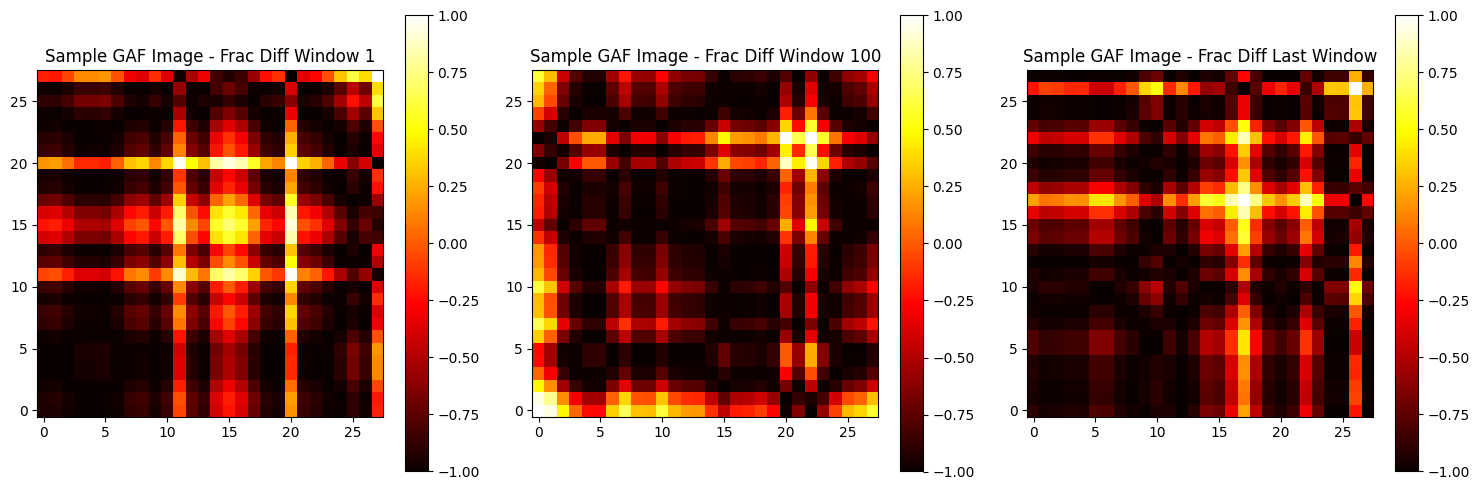

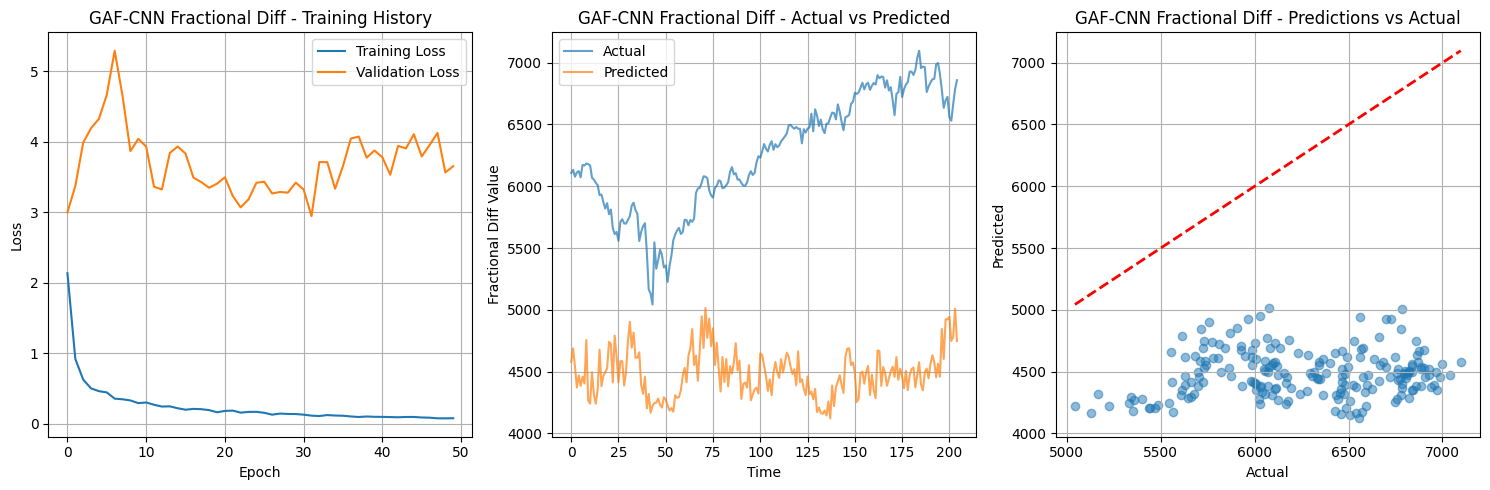


3.c COMPLETED: CNN with GAF for Fractionally Differenced Series


In [ ]:
# -----------------------------------------------------------------
# STEP 3.c: CNN WITH GAF FOR FRACTIONALLY DIFFERENCED SERIES
# -----------------------------------------------------------------

print("\n" + "="*60)
print("STEP 3.c: CNN WITH GAF FOR FRACTIONALLY DIFFERENCED SERIES")
print("="*60)

print("Preparing Fractionally Differenced data for GAF-CNN...")

# Apply fractional differencing
d = 0.5
frac_diff_data = fractional_diff_ffd(data['Close'], d).dropna().values

# Create rolling windows
X_frac_windows, y_frac = create_rolling_windows(frac_diff_data, window_size, prediction_horizon)

print(f"Created {len(X_frac_windows)} rolling windows")

# Create GAF images for each window
X_frac_gaf = []
for i, window in enumerate(X_frac_windows):
    gaf_image = create_gaf_images(window, image_size=image_size)
    X_frac_gaf.append(gaf_image)

X_frac_gaf = np.array(X_frac_gaf)
X_frac_gaf = X_frac_gaf.reshape(X_frac_gaf.shape[0], image_size, image_size, 1)

print(f"GAF images shape: {X_frac_gaf.shape}")

# Split data
split_idx = int(len(X_frac_gaf) * (1 - test_size))
X_train_frac_gaf, X_test_frac_gaf = X_frac_gaf[:split_idx], X_frac_gaf[split_idx:]
y_train_frac, y_test_frac = y_frac[:split_idx], y_frac[split_idx:]

# Scale target for fractional diff (it's not naturally bounded like returns)
scaler_y_frac = StandardScaler()
y_train_frac_scaled = scaler_y_frac.fit_transform(y_train_frac.reshape(-1, 1)).flatten()
y_test_frac_scaled = scaler_y_frac.transform(y_test_frac.reshape(-1, 1)).flatten()

print(f"Training samples: {X_train_frac_gaf.shape[0]}")
print(f"Test samples: {X_test_frac_gaf.shape[0]}")

# Build and train CNN model
print("\nBuilding and training CNN with GAF for Fractionally Differenced Series...")
model_gaf_frac = build_cnn_model(input_shape=(image_size, image_size, 1))
model_gaf_frac.summary()

# Train the model
history_gaf_frac = model_gaf_frac.fit(
    X_train_frac_gaf, y_train_frac_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Make predictions
y_pred_gaf_frac_scaled = model_gaf_frac.predict(X_test_frac_gaf, verbose=0).flatten()
y_pred_gaf_frac = scaler_y_frac.inverse_transform(y_pred_gaf_frac_scaled.reshape(-1, 1)).flatten()

# Calculate metrics
mse_gaf_frac = mean_squared_error(y_test_frac, y_pred_gaf_frac)
mae_gaf_frac = mean_absolute_error(y_test_frac, y_pred_gaf_frac)

print(f"\nGAF-CNN Fractional Diff Model Results:")
print(f"MSE: {mse_gaf_frac:.6f}")
print(f"MAE: {mae_gaf_frac:.6f}")

# Plot sample GAF images for fractional diff
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(X_frac_gaf[0, :, :, 0], cmap='hot', origin='lower')
plt.title('Sample GAF Image - Frac Diff Window 1')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(X_frac_gaf[100, :, :, 0], cmap='hot', origin='lower')
plt.title('Sample GAF Image - Frac Diff Window 100')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(X_frac_gaf[-1, :, :, 0], cmap='hot', origin='lower')
plt.title('Sample GAF Image - Frac Diff Last Window')
plt.colorbar()

plt.tight_layout()
plt.show()

# Plot results
plt.figure(figsize=(15, 5))

# Training history
plt.subplot(1, 3, 1)
plt.plot(history_gaf_frac.history['loss'], label='Training Loss')
plt.plot(history_gaf_frac.history['val_loss'], label='Validation Loss')
plt.title('GAF-CNN Fractional Diff - Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Predictions vs Actual
plt.subplot(1, 3, 2)
plt.plot(y_test_frac, label='Actual', alpha=0.7)
plt.plot(y_pred_gaf_frac, label='Predicted', alpha=0.7)
plt.title('GAF-CNN Fractional Diff - Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Fractional Diff Value')
plt.legend()
plt.grid(True)

# Scatter plot
plt.subplot(1, 3, 3)
plt.scatter(y_test_frac, y_pred_gaf_frac, alpha=0.5)
plt.plot([y_test_frac.min(), y_test_frac.max()], [y_test_frac.min(), y_test_frac.max()], 'r--', lw=2)
plt.title('GAF-CNN Fractional Diff - Predictions vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)

plt.tight_layout()
plt.show()

# Store results for later comparison
results_gaf_frac = {
    'model': 'GAF-CNN Fractional Diff',
    'mse': mse_gaf_frac,
    'mae': mae_gaf_frac,
    'predictions': y_pred_gaf_frac,
    'actual': y_test_frac,
    'model_object': model_gaf_frac
}

print("\n" + "="*50)
print("3.c COMPLETED: CNN with GAF for Fractionally Differenced Series")
print("="*50)

## 3.d


STEP 3.d: CNN-GAF MODEL COMPARISON AND EVALUATION

--- GAF-CNN PERFORMANCE COMPARISON ---
                     Model           MSE          MAE
0     GAF-CNN Price Levels  5.821439e+06  2354.028117
1      GAF-CNN Log Returns  1.428593e-04     0.007963
2  GAF-CNN Fractional Diff  3.371418e+06  1769.703157

 BEST GAF-CNN MODEL BY MSE: GAF-CNN Log Returns (MSE: 0.000143)
 BEST GAF-CNN MODEL BY MAE: GAF-CNN Log Returns (MAE: 0.007963)


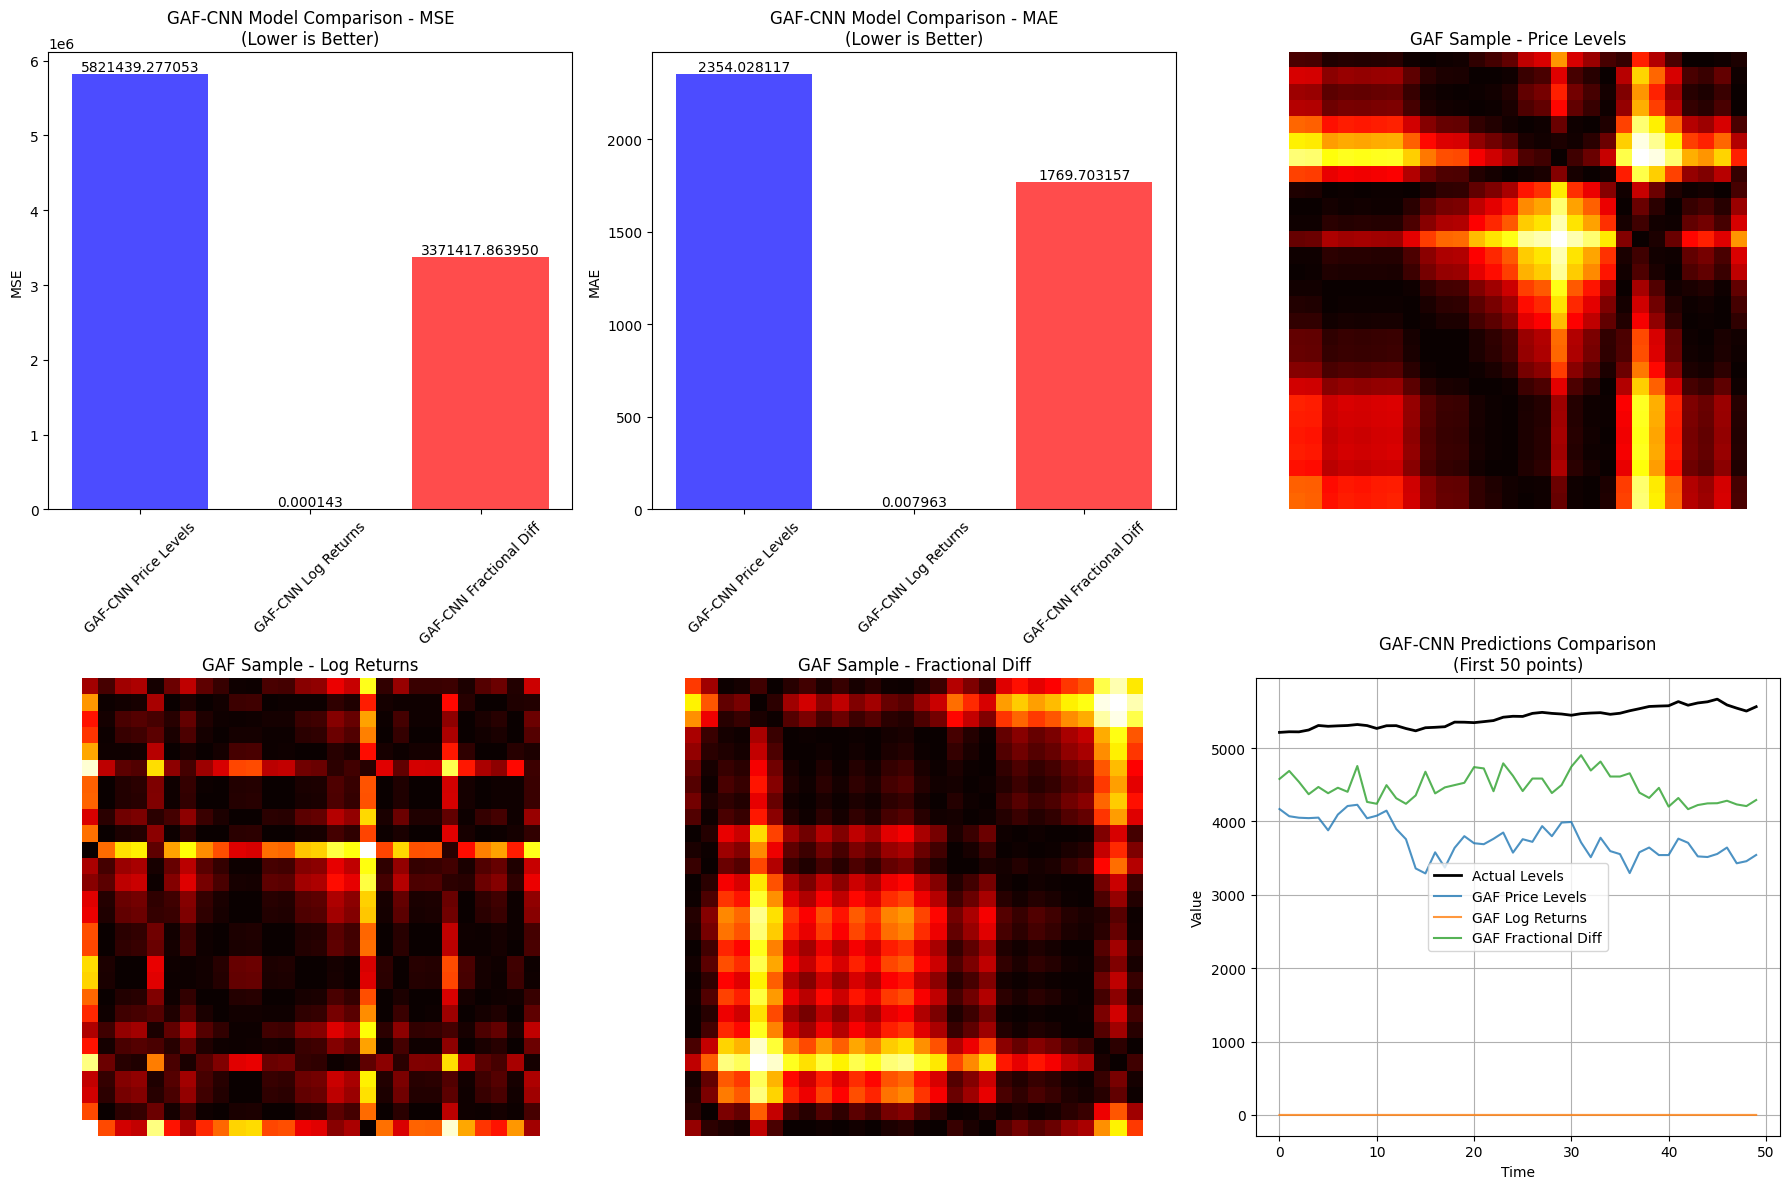


--- COMPREHENSIVE MLP vs GAF-CNN COMPARISON ---
                     Model           MSE          MAE
0         MLP Price Levels  1.023226e+05   309.306957
1          MLP Log Returns  1.159773e-04     0.007119
2      MLP Fractional Diff  2.604793e+04   142.599103
3     GAF-CNN Price Levels  5.821439e+06  2354.028117
4      GAF-CNN Log Returns  1.428593e-04     0.007963
5  GAF-CNN Fractional Diff  3.371418e+06  1769.703157

 OVERALL BEST MODEL BY MSE: MLP Log Returns (MSE: 0.000116)
 OVERALL BEST MODEL BY MAE: MLP Log Returns (MAE: 0.007119)

STEP 3 COMPLETED: All GAF-CNN Models Built and Evaluated


In [ ]:
# -----------------------------------------------------------------
# STEP 3.d: CNN-GAF MODEL COMPARISON AND EVALUATION
# -----------------------------------------------------------------

print("\n" + "="*60)
print("STEP 3.d: CNN-GAF MODEL COMPARISON AND EVALUATION")
print("="*60)

# Combine all GAF-CNN results
all_gaf_results = [results_gaf_levels, results_gaf_returns, results_gaf_frac]

# Create comparison table
gaf_comparison_data = []
for result in all_gaf_results:
    gaf_comparison_data.append({
        'Model': result['model'],
        'MSE': result['mse'],
        'MAE': result['mae']
    })

gaf_comparison_df = pd.DataFrame(gaf_comparison_data)
print("\n--- GAF-CNN PERFORMANCE COMPARISON ---")
print(gaf_comparison_df)

# Find best GAF-CNN models
best_gaf_mse_model = gaf_comparison_df.loc[gaf_comparison_df['MSE'].idxmin()]
best_gaf_mae_model = gaf_comparison_df.loc[gaf_comparison_df['MAE'].idxmin()]

print(f"\n BEST GAF-CNN MODEL BY MSE: {best_gaf_mse_model['Model']} (MSE: {best_gaf_mse_model['MSE']:.6f})")
print(f" BEST GAF-CNN MODEL BY MAE: {best_gaf_mae_model['Model']} (MAE: {best_gaf_mae_model['MAE']:.6f})")

# Comprehensive visualization for GAF-CNN models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Performance metrics comparison
gaf_models = gaf_comparison_df['Model']
gaf_mse_values = gaf_comparison_df['MSE']
gaf_mae_values = gaf_comparison_df['MAE']

axes[0, 0].bar(gaf_models, gaf_mse_values, color=['blue', 'green', 'red'], alpha=0.7)
axes[0, 0].set_title('GAF-CNN Model Comparison - MSE\n(Lower is Better)')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(gaf_mse_values):
    axes[0, 0].text(i, v, f'{v:.6f}', ha='center', va='bottom')

axes[0, 1].bar(gaf_models, gaf_mae_values, color=['blue', 'green', 'red'], alpha=0.7)
axes[0, 1].set_title('GAF-CNN Model Comparison - MAE\n(Lower is Better)')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(gaf_mae_values):
    axes[0, 1].text(i, v, f'{v:.6f}', ha='center', va='bottom')

# 2. GAF image patterns comparison (show one sample from each)
sample_indices = [0, 100, 200]

axes[0, 2].imshow(X_gaf[sample_indices[0], :, :, 0], cmap='hot', origin='lower')
axes[0, 2].set_title('GAF Sample - Price Levels')
axes[0, 2].axis('off')

axes[1, 0].imshow(X_returns_gaf[sample_indices[1], :, :, 0], cmap='hot', origin='lower')
axes[1, 0].set_title('GAF Sample - Log Returns')
axes[1, 0].axis('off')

axes[1, 1].imshow(X_frac_gaf[sample_indices[2], :, :, 0], cmap='hot', origin='lower')
axes[1, 1].set_title('GAF Sample - Fractional Diff')
axes[1, 1].axis('off')

# 3. Predictions comparison
axes[1, 2].plot(results_gaf_levels['actual'][:50], label='Actual Levels', linewidth=2, color='black')
axes[1, 2].plot(results_gaf_levels['predictions'][:50], label='GAF Price Levels', alpha=0.8)
axes[1, 2].plot(results_gaf_returns['predictions'][:50], label='GAF Log Returns', alpha=0.8)
axes[1, 2].plot(results_gaf_frac['predictions'][:50], label='GAF Fractional Diff', alpha=0.8)
axes[1, 2].set_title('GAF-CNN Predictions Comparison\n(First 50 points)')
axes[1, 2].set_xlabel('Time')
axes[1, 2].set_ylabel('Value')
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.tight_layout()
plt.show()

# Compare with previous MLP results (if available)
try:
    # Assuming MLP results are stored from previous step
    mlp_comparison_data = [
        {'Model': 'MLP Price Levels', 'MSE': results_levels['mse'], 'MAE': results_levels['mae']},
        {'Model': 'MLP Log Returns', 'MSE': results_returns['mse'], 'MAE': results_returns['mae']},
        {'Model': 'MLP Fractional Diff', 'MSE': results_frac['mse'], 'MAE': results_frac['mae']}
    ]

    mlp_comparison_df = pd.DataFrame(mlp_comparison_data)

    # Combine MLP and GAF-CNN results
    all_models_df = pd.concat([mlp_comparison_df, gaf_comparison_df], ignore_index=True)

    print("\n--- COMPREHENSIVE MLP vs GAF-CNN COMPARISON ---")
    print(all_models_df)

    # Find overall best model
    best_overall_mse = all_models_df.loc[all_models_df['MSE'].idxmin()]
    best_overall_mae = all_models_df.loc[all_models_df['MAE'].idxmin()]

    print(f"\n OVERALL BEST MODEL BY MSE: {best_overall_mse['Model']} (MSE: {best_overall_mse['MSE']:.6f})")
    print(f" OVERALL BEST MODEL BY MAE: {best_overall_mae['Model']} (MAE: {best_overall_mae['MAE']:.6f})")

except NameError:
    print("\nNote: MLP results not available for comparison. Run Step 2 first for full comparison.")

print("\n" + "="*60)
print("STEP 3 COMPLETED: All GAF-CNN Models Built and Evaluated")
print("="*60)